# 06 — Director outputs (the curated few)

The presentation set, mirroring the northern `07_director_outputs` and the y2y trail
(`analyses/y2y/21_director_outputs`): only the maps that go on slides, each ONE asset function in
`wolverine_director` drawn through `director_plot.wide_map` — the y2y Act 1 **wide layout** (13.33 × 7.5 in
slide: the whole Y2Y frame at left, zoom insets A and B stacked at right, the key under A, the legend
centred between inset B and the page bottom; hillshade + Natural Earth basemap; PNG at 300 dpi + PDF). Colours and words come from
`corridors_mapstyle` (the §3a tokens); the frame draws at 600 m (one 300 dpi pixel of the frame panel is
~1.5 km). The refugia nodes are the overlay (sea-green fill, thin outline); 01, 02 and 04 draw no protected land; 03
adds it as one grey layer (existing PAs + proposed IPCAs / PAs, 85%) UNDER the corridor pressure — corridor
land over grey is already inside protected land (W11). Knobs: `wd.WIDE_STYLE` (then
`dp.STYLE`), `wd.STYLE`; `INSETS` = "examples" (A = the northernmost example link, B = the southernmost)
or "clusters" (the two densest node clusters).

Outputs → `analyses/wolverine_refugia_connectivity/director_package/director_outputs/` (PNG at 300 dpi; the PDF twin was retired 2026-10-01) — the y2y / Alberta
folder structure since 2026-10-01 (`wd.PKG_DIR`; `summary.json` names the run; a package built from another run first moves to
`_superseded_<run>/`). The full record (every asset, tables, GIS, QA) is `04_tables_and_figures.ipynb`.

In [1]:
# ---- Setup: find the project root, import the shared engines ----------------
# This notebook lives in analyses/wolverine_refugia_connectivity/, below the repo root where
# config.py and the corridor engine modules sit. Same bootstrap as analyses/northern_connectivity/.
import sys, pathlib, json
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import numpy as np
import pandas as pd
import config
import corridors_prep as cp
import corridor_graph as cg
import corridors_core as cc
for _m in (config, cp, cg, cc):
    importlib.reload(_m)

KEY = "wolverine"
CFG = config.CORRIDORS[KEY]
HERE = ROOT / "analyses" / "wolverine_refugia_connectivity"

import matplotlib.pyplot as plt
import corridors_mapstyle as ms          # the §3a tokens: class + cost colours and words
import corridors_director as cd
import director_plot as dp               # the y2y Act 1 wide layout (one codebase with analyses/y2y/21 and the northern 07)
import wolverine_director as wd
for _m in (ms, cd, dp, wd):
    importlib.reload(_m)

import wolverine_postprocess as wp
importlib.reload(wp)
RUN = "v2_run001"                        # <-- the node-level run (run spec v3 §1a, 2026-09-29: v2 as routed, fronts on the pressure scale)
INSETS = "fixed"                         # "fixed" (A = the Nahanni links south, B = Missoula-Helena-Salmon-Bozeman; 312 x 346 km) | "examples" | "clusters"
wd.STYLE.update(wd.V25_STYLE)            # two acts; no protected layers; refugia in the 01 scheme; nodes numbered; fronts tinted; no pinch
R = wp.attach_nodes(cc.load_results(config.RESULTS_DIR / CFG["results_subdir"] / RUN))    # the node-level product from 05_postprocess
P = wd.package(R)
acts = json.loads((R.run_dir / "postprocess" / "acts.json").read_text()) if (R.run_dir / "postprocess" / "acts.json").exists() else {}
if acts.get("break_moved"):              # the act check of 06: the Bow Valley rule, re-applied here
    wd.STYLE["act_breaks_lat"] = tuple(acts["act_breaks_lat"]); P = wd.package(R); P.act_note = acts.get("note", "")
F = wd.director_frame(P)                 # the run as a director_plot frame: 600 m grid, PAs grey, the refugia nodes as the overlay, the Y2Y window
dp.STYLE.update(wd.WIDE_STYLE)           # the wolverine knobs for the wide layout -- tweak dp.STYLE HERE, after this line, before drawing
plt.rcParams.update(dp.SPEC_RC)
OUT = P.out / "director_outputs"; OUT.mkdir(exist_ok=True)
print(f"frame {F.G.shape} @ {1000 / F.PX_PER_KM:.0f} m · window px {tuple(round(v) for v in F.WINDOW)} · insets {INSETS} → {OUT}")

v2_run001: results context loaded (170 edges, 44 branches, corridor 52,572 km²)
attached node-level product: 130 nodes, 130 fronts + 40 strips on one pressure scale
wolverine package: classes -> only viable 19 · last affordable 28 · narrowing 30 · options 93 | geometric classes first (D25/D24): adjacent 0 (barrier between 0), width not assessable 0 | 130 nodes | 4 examples | H8 closed | already connected: 26 within existing PAs, 23 only with the proposed IPCAs (mode 'overlay')
frame (5519, 2143) @ 600 m · window px (-33, 2175, -33, 5552) · insets fixed → /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs


## 01 — the movement-cost surface

What the land is made of on the surface the corridors were routed on ("O'Brien 2025, generic terrain rules
withheld"): the movement-cost classes in the M0b magma swatches (1 intact · 10 roads and forestry cutblocks · 100
farmland and other converted land · 1,000 split for the reader into open water, in a blue-purple, and settlement / other
retained barriers, in magma's dark — same cost, different meaning; `wd.STYLE["cost_split_water"]`), existing PAs grey, proposed IPCAs filled, the
refugia nodes filled + outlined, postal codes on the frame, names + towns in the insets. The class shares
print for the slide's subtitle. The surface and its key draw at `wd.STYLE["cost_surface_alpha"]` (0.70) so the
provincial boundaries show through.


movement cost (withheld-terrain surface), share of the routable area: 1: 81.4% · 10: 10.0% · 100: 2.0% · 1000 water: 1.1% · 1000 settlement: 5.5%
  insets (fixed): 312 x 346 km each


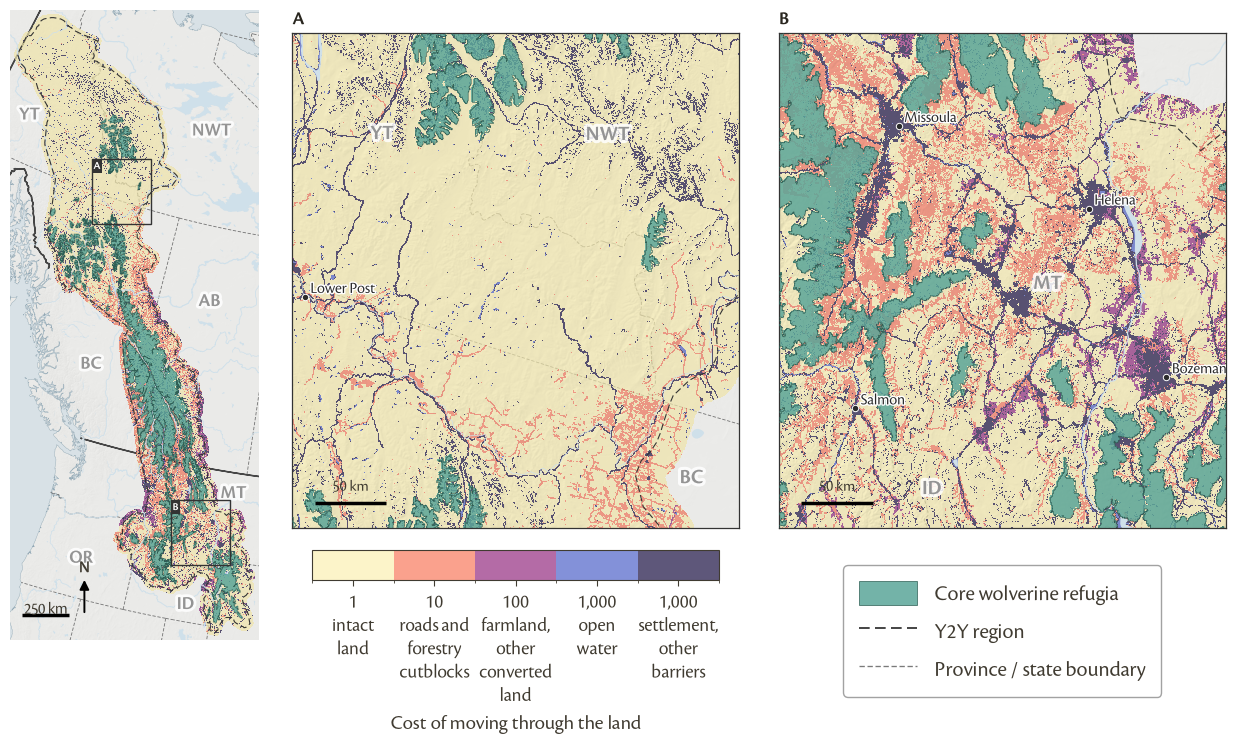

legend: 2 insets · items at 16 pt (fit to the gap under inset B; configured 16 pt)


PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs/01_movement_cost.png')

In [2]:
wd.figure_cost_wide(P, OUT / "01_movement_cost.png", insets=INSETS)      # nodes = the complexes

## 02 — the network by corridor pressure, one scale (run spec v3 §8)

Strips at full weight in the ramp slot (the key); fronts (the near-contiguous links) as bands in their class colour -- open fronts
as the light tint, cut fronts (narrow, or a cost >= 10 on the path) at full strength with an outline; the refugia as on 01; no
protected layers (that analysis is a separate product); nodes numbered until names are chosen.

  insets (fixed): 312 x 346 km each
strips per class: securing 93 · squeezed 30 · edge 28 · both 19 | fronts 130 | 130 nodes | already connected: 26 within existing PAs, 23 once the proposed IPCAs are realized | band = about 4.1 km of extra travel on open ground


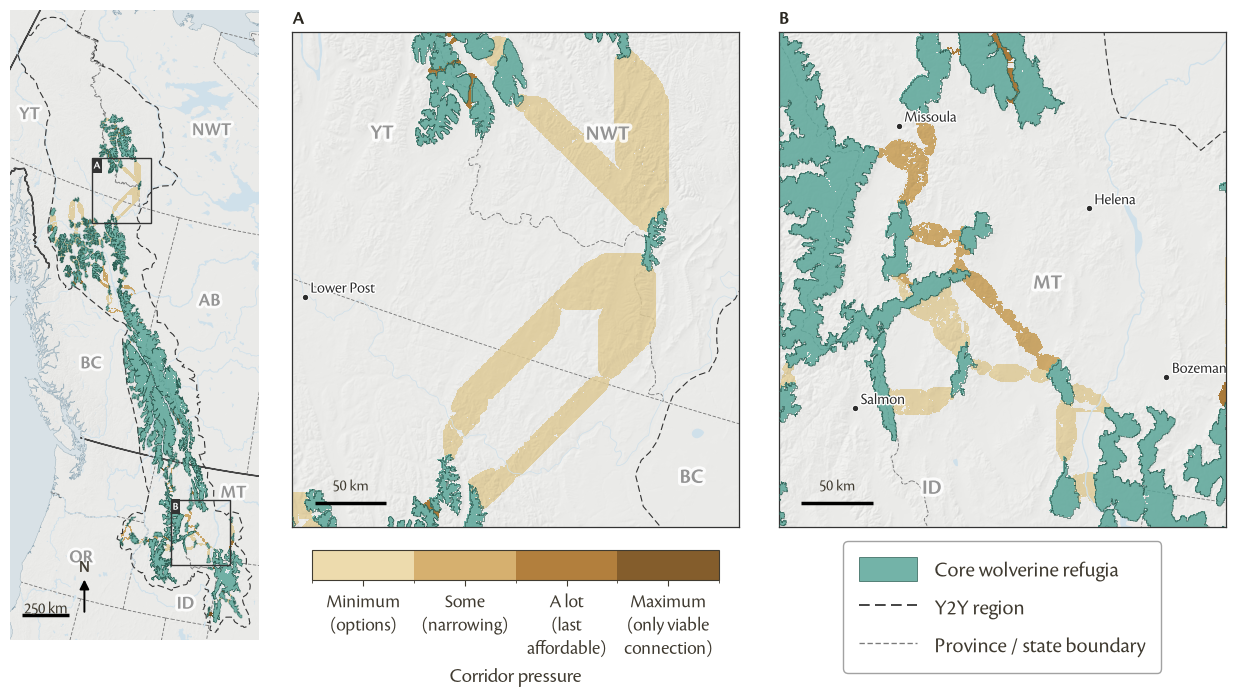

legend: 2 insets · items at 16 pt (fit to the gap under inset B; configured 16 pt)


PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs/02_corridor_pressure.png')

In [3]:
wd.figure_network_wide(P, OUT / "02_corridor_pressure.png", insets=INSETS)

## 03 — protected land under the network

02's surface and key (the corridor pressure) with protected land drawn UNDER the bands as ONE grey layer: the existing
protected areas and the proposed IPCAs / PAs together (the layout's PA grey `#8f8f8f`, `director_plot.PA_COLOR`, at 85%),
so every band keeps its class colour and the grey reads through it at the surface's alpha — corridor land over grey is
already inside protected land, existing or proposed (W11). The refugia as on 01; the largest PAs and proposed areas named in each inset
(`wd.STYLE["protection_pa_names"]` 4 / `["protection_ipca_names"]` 3, proposed ones suffixed ", proposed"; a name is placed only where its box overlaps no other text, and town
labels flip clear of the codes and names — no text overlaps); `wd.STYLE["protection_zorder"] = 1.0` puts the grey back on top. This map's surface
and key draw at `wd.STYLE["protection_surface_alpha"]` (0.65, lower than 02/04's 0.85) so band-over-protected-land reads. Prints the corridor
land inside existing PAs / inside the proposed IPCAs only / outside both, for the slide.


  insets (fixed): 312 x 346 km each
corridor land 52,572 km²: inside existing PAs 12,816 (24%) · inside the proposed IPCAs / PAs only 5,848 (11%) · outside both 33,907 (64%) | links already connected: 26 within existing PAs, 23 once the IPCAs are realized


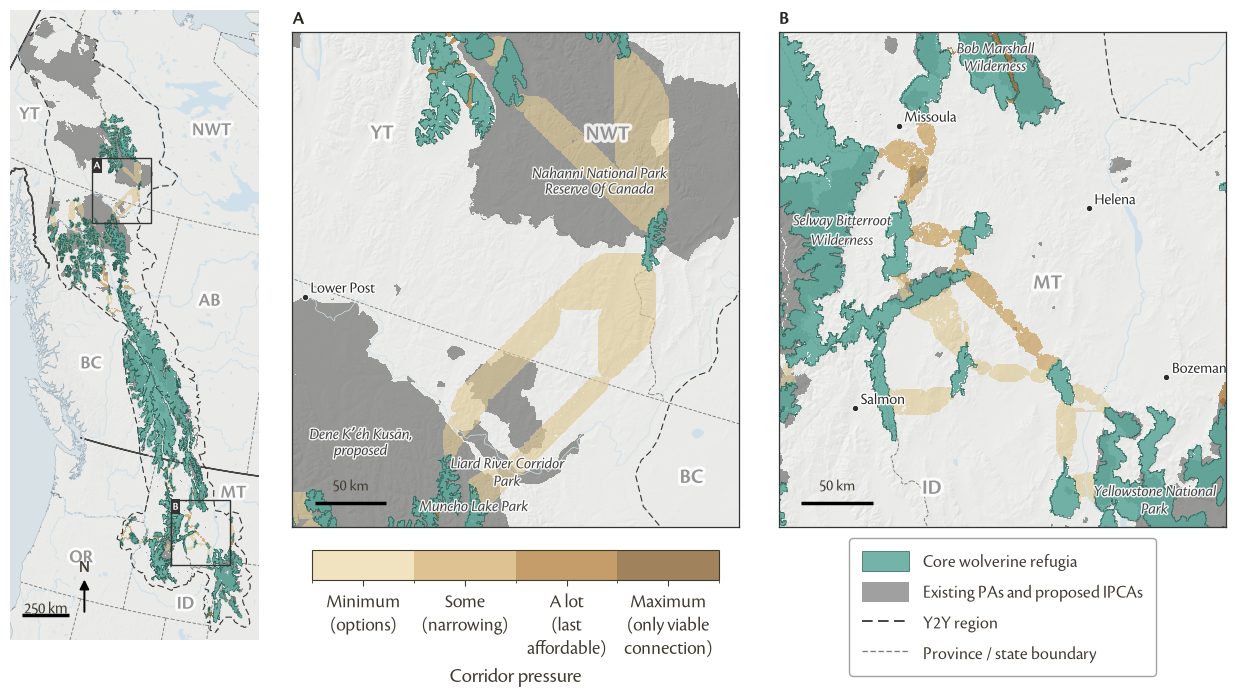

names placed: ['Nahanni National Park Reserve Of Canada', 'Liard River Corridor Park', 'Muncho Lake Park', 'Dene Kʼéh Kusān, proposed', 'Selway Bitterroot Wilderness', 'Yellowstone National Park', 'Bob Marshall Wilderness'] · town labels flipped 0, hidden 0
legend: 2 insets · items at 13 pt (fit to the gap under inset B; configured 16 pt)


PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs/03_protected_land.png')

In [4]:
wd.figure_protection_wide(P, OUT / "03_protected_land.png", insets=INSETS)

## 04 — the route options

03's map (the pressure surface over the grey protected land, PA and proposed-area names) with the deck's four route options
OUTLINED in their number's colour (the y2y cluster palette: 1 red, 2 blue, 3 magenta, 4 orange, the same as the stars and the
consequences columns), so each band's pressure fill still shows, and numbered 1–4 by the northern placer (outside the band,
no leader, clear of every other label). Pinned in `wd.EXAMPLE_PICKS` by link id, numbered north → south: inset A = options
1–2, the Nahanni node's two links south to the Muncho Lake refugia (outside Nahanni National Park Reserve); inset B = 3–4,
Selway-Bitterroot ↔ Lee Metcalf (one part) and Selway-Bitterroot ↔ Skull-Odell (two route branches). Knobs:
`wd.STYLE["option_style"]` ("outline" | "fill"), `["option_legend"]`, `["options_protected"]`. No text overlaps: names are
placed only where their box is clear, town labels flip away from codes and names.


  insets (fixed): 312 x 346 km each
route options: 1 #D7263D at px (979, 1634) (nw) · 2 #1E90FF at px (1058, 1669) (se) · 3 #E040A0 at px (1666, 4646) (ne) · 4 #FF7F00 at px (1560, 4738) (sw)


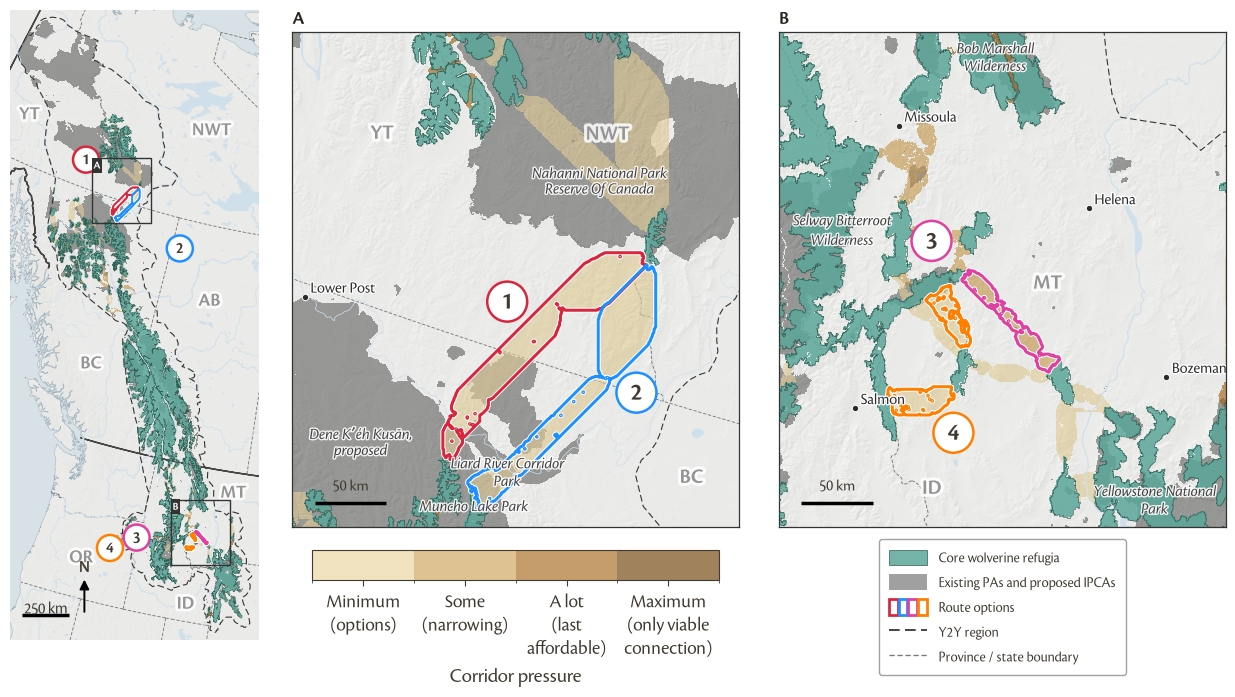

names placed: ['Nahanni National Park Reserve Of Canada', 'Liard River Corridor Park', 'Muncho Lake Park', 'Dene Kʼéh Kusān, proposed', 'Selway Bitterroot Wilderness', 'Yellowstone National Park', 'Bob Marshall Wilderness'] · town labels flipped 0, hidden 0
legend: 2 insets · items at 10.5 pt (fit to the gap under inset B; configured 16 pt)


PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs/04_route_options.png')

In [5]:
wd.figure_options_wide(P, OUT / "04_route_options.png", insets=INSETS)

## 05 — the route options: star plots + locators

The y2y Act 1 stars (`director_plot.star_grid`, one star per option in its colour): each axis = the option's mean
PERCENTILE of a theme against the Y2Y-wide allocatable landscape (`director_core.block_percentiles`; dashed ring 0.5 =
the typical unprotected cell; fractional 300 m → 1 km cover). Under them, the two inset windows A and B as locator
panels on the star grid's geometry. The first call computes the y2y layers' percentiles (~1–2 min) and caches them on `P`.

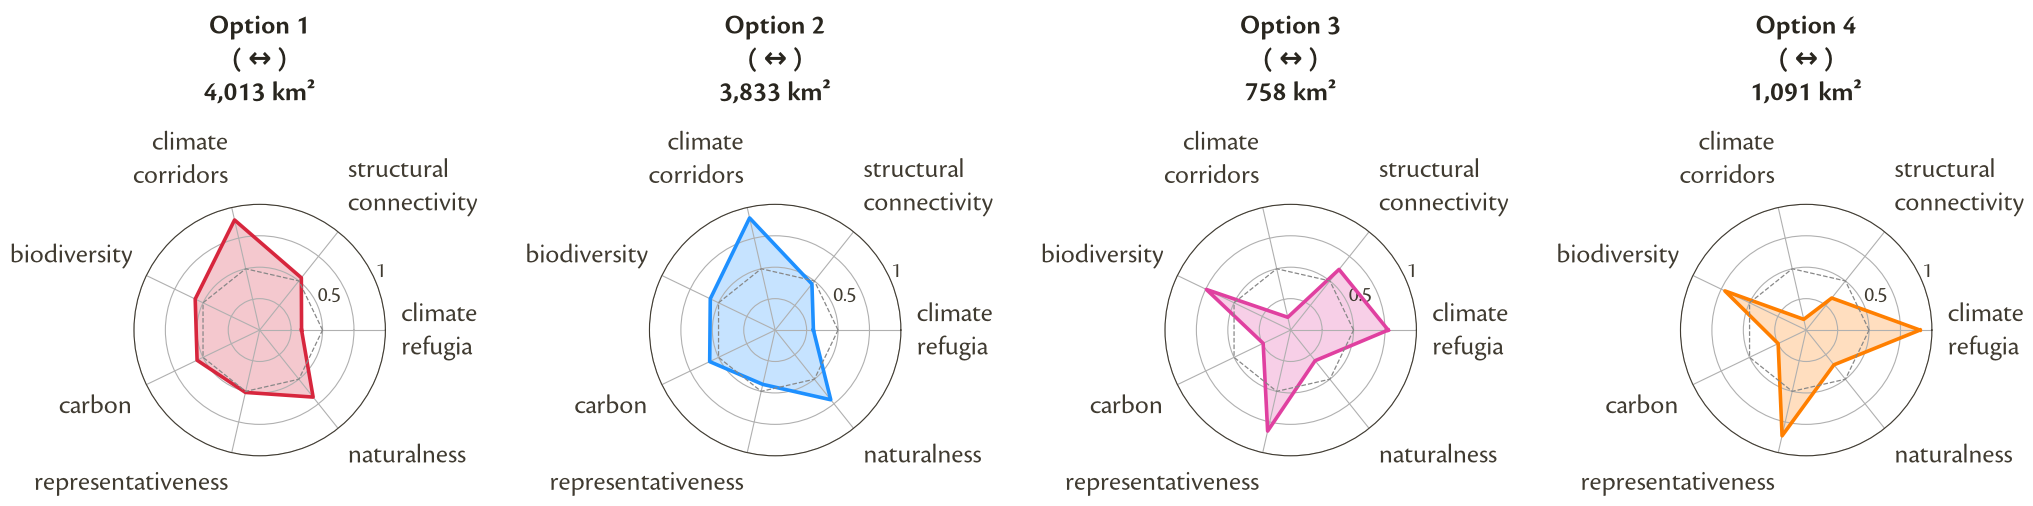

  insets (fixed): 312 x 346 km each


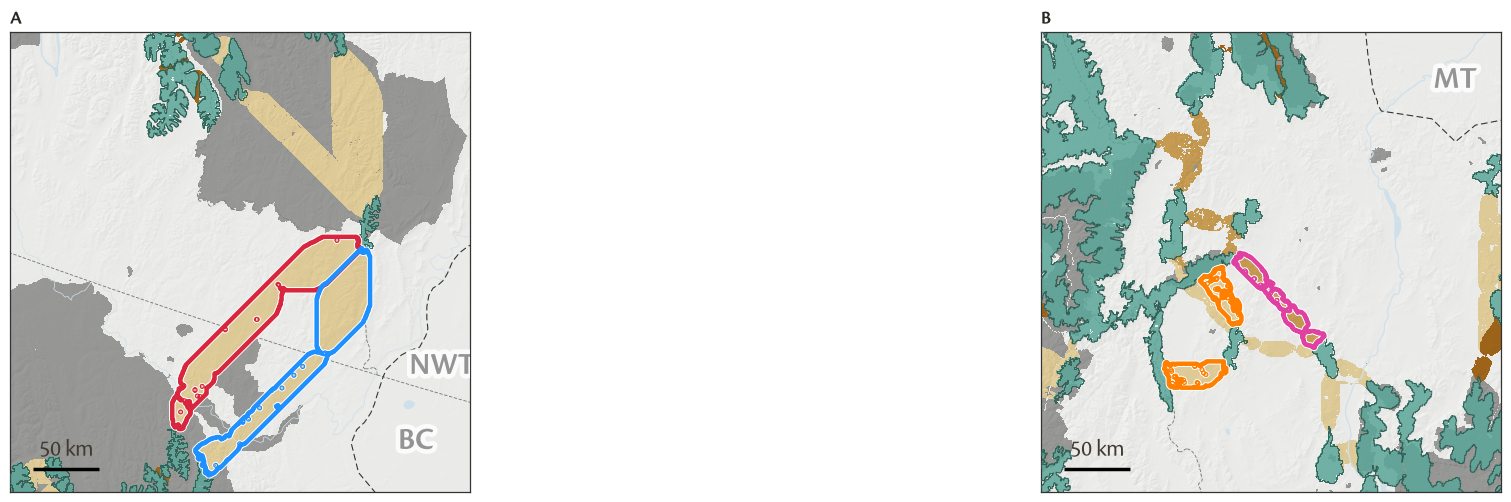

PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/director_outputs/05b_route_option_locators.png')

In [6]:
wd.option_stars(P, OUT / "05_route_option_stars.png")
wd.option_locators(P, OUT / "05b_route_option_locators.png", insets=INSETS, panel_px=620)   # + each panel as its own file (_A, _B)

## 06 — the route options: consequences

The y2y consequences table (`director_plot.consequences_table`, transposed, per-row red → blue fills over the option
columns): mean raw value in the option's land ÷ mean over Y2Y-wide allocatable land, per theme ("2.3×" = 2.3 times the
average unprotected cell), columns = the options then two reference areas — Banff National Park (existing PA) and
Dene Kʼéh Kusān (proposed IPCA), the y2y tables' rule (`wd.CONSEQ_REFERENCE`). Rows also to
`director_package/tables/route_option_consequences.csv` (`analyses/wolverine_refugia_connectivity/director_package/` since 2026-10-01).

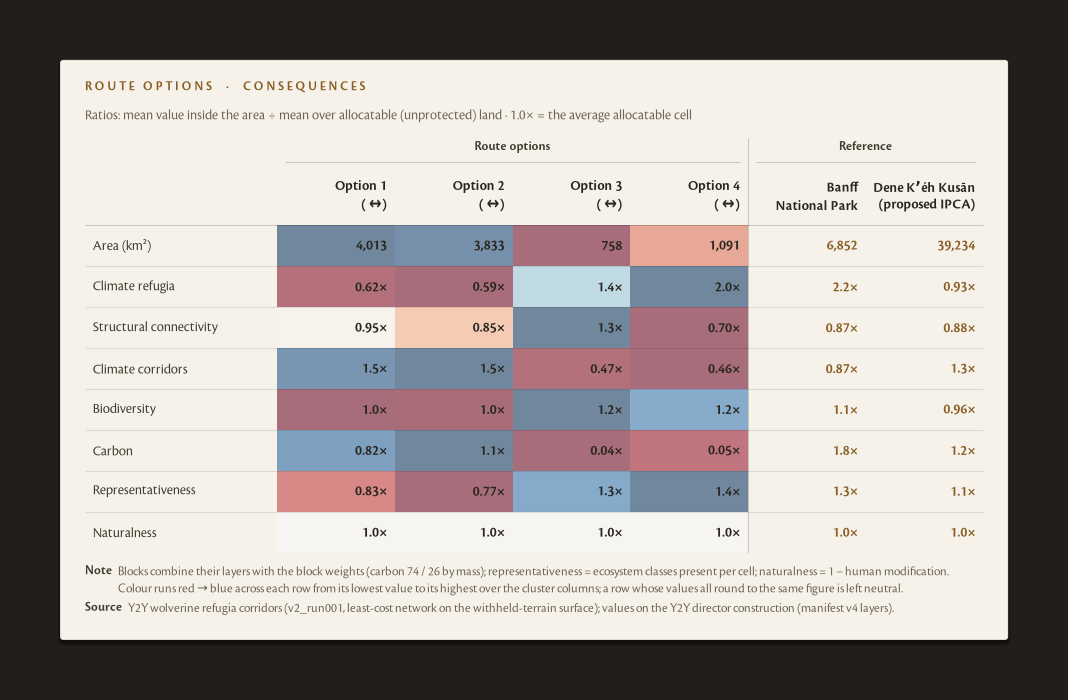

,kind,number,name,area_km2,pct_core habitat,pct_structural connectivity,pct_climate corridors,pct_biodiversity,pct_carbon,pct_representativeness,pct_naturalness,ratio_core habitat,ratio_structural connectivity,ratio_climate corridors,ratio_biodiversity,ratio_carbon,ratio_representativeness,ratio_naturalness
0,option,1,↔,4012.56,0.333111,0.531564,0.898048,0.569065,0.552524,0.508604,0.681706,0.618837,0.951043,1.451328,1.038795,0.822784,0.834646,1.047475
1,option,2,↔,3833.46,0.304108,0.468826,0.914510,0.572919,0.578166,0.443046,0.708904,0.594956,0.850909,1.538046,1.039748,1.073743,0.772532,1.048256
2,option,3,↔,758.07,0.775512,0.616936,0.104431,0.744125,0.243085,0.823971,0.311514,1.373860,1.328689,0.471794,1.231941,0.044426,1.262927,1.014257
3,option,4,↔,1091.07,0.904782,0.325894,0.087539,0.717825,0.247712,0.862472,0.353558,1.981608,0.696449,0.456287,1.205337,0.053658,1.352883,1.021301
4,reference,,Banff National Park,6852.06,0.898979,0.335816,0.367295,0.570596,0.666334,0.784582,0.604589,2.228842,0.865279,0.873242,1.053504,1.818549,1.266351,1.028521
5,reference,,Dene Kʼéh Kusān (proposed IPCA),39234.06,0.607513,0.463628,0.699714,0.484700,0.591726,0.750564,0.662825,0.933032,0.879385,1.274871,0.964543,1.174229,1.122385,1.046620


In [7]:
wd.option_consequences(P, OUT / "06_route_option_consequences.png")